<a href="https://colab.research.google.com/github/KarimAmr05/Flowers-Recognition/blob/main/Flowers_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# 1. Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')



# 2. Imports

import cv2
import random
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



# 3. Dataset Path

image_dir = Path('/content/drive/MyDrive/datasets/flowers')



# 4. Feature Extraction (HOG + LAB Color)

def extract_features(image_path):
    img = cv2.imread(str(image_path))
    img = cv2.resize(img, (128, 128))

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)

    hog_features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        block_norm='L2-Hys'
    )

    l_hist = cv2.calcHist([lab], [0], None, [32], [0, 256])
    a_hist = cv2.calcHist([lab], [1], None, [32], [0, 256])
    b_hist = cv2.calcHist([lab], [2], None, [32], [0, 256])

    color_features = np.concatenate([l_hist, a_hist, b_hist]).flatten()

    return np.concatenate([hog_features, color_features])



# 5. Sample 300 Images per Class (1500 Total)

X = []
y = []
image_paths = []
labels_text = []

class_names = sorted([d.name for d in image_dir.iterdir() if d.is_dir()])
samples_per_class = 300

for label, class_name in enumerate(class_names):
    class_path = image_dir / class_name
    images = list(class_path.glob('*'))
    sampled_images = random.sample(images, samples_per_class)

    for img_path in sampled_images:
        X.append(extract_features(img_path))
        y.append(label)
        image_paths.append(img_path)
        labels_text.append(class_name)

X = np.array(X)
y = np.array(y)

print("Total samples:", len(X))
print("Classes:", class_names)



# 6. Train-Test Split

X_train, X_test, y_train, y_test, paths_train, paths_test, labels_train, labels_test = train_test_split(
    X, y, image_paths, labels_text,
    test_size=0.2,
    random_state=42,
    stratify=y
)



# 7. Feature Scaling

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)




Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Total samples: 1500
Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']



Accuracy: 0.49333333333333335

Classification Report:
              precision    recall  f1-score   support

       daisy       0.40      0.40      0.40        60
   dandelion       0.54      0.43      0.48        60
        rose       0.45      0.45      0.45        60
   sunflower       0.52      0.57      0.54        60
       tulip       0.55      0.62      0.58        60

    accuracy                           0.49       300
   macro avg       0.49      0.49      0.49       300
weighted avg       0.49      0.49      0.49       300



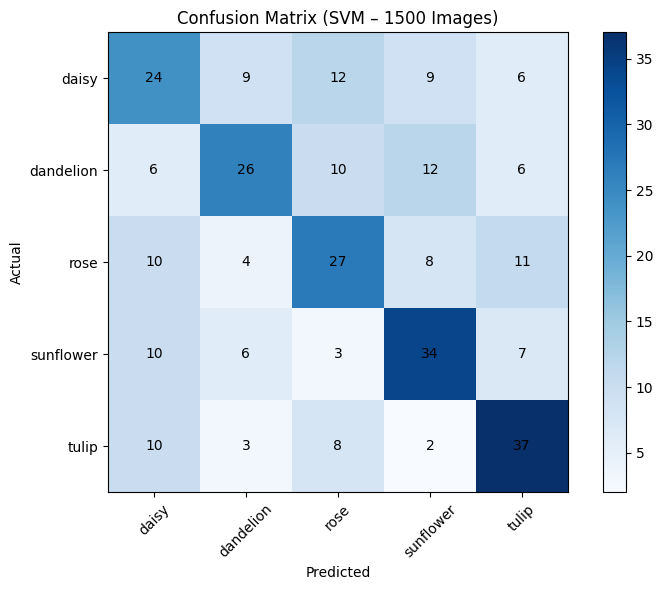

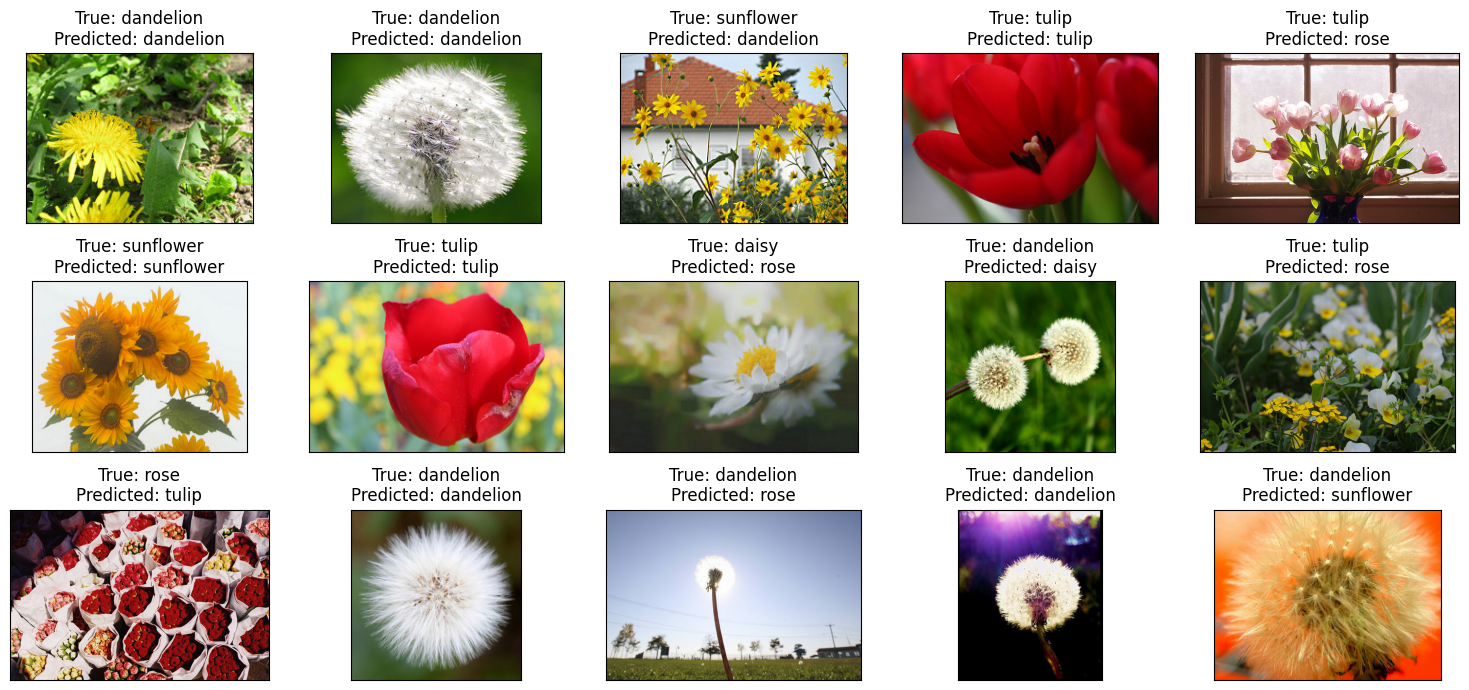

In [ ]:

# 8. Train SVM (Stable & Data-Friendly)

svm_model = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    class_weight='balanced'
)

svm_model.fit(X_train, y_train)



# 9. Evaluation

y_pred = svm_model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=class_names))



# 10. Confusion Matrix (WITH NUMBERS)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix (SVM – 1500 Images)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.xticks(range(len(class_names)), class_names, rotation=45)
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()



# 11. Display 15 Images with True & Predicted Labels

fig, axes = plt.subplots(
    nrows=3,
    ncols=5,
    figsize=(15, 7),
    subplot_kw={'xticks': [], 'yticks': []}
)

for i, ax in enumerate(axes.flat):
    img = plt.imread(paths_test[i])
    ax.imshow(img)
    ax.set_title(
        f"True: {labels_test[i]}\nPredicted: {class_names[y_pred[i]]}"
    )

plt.tight_layout()
plt.show()
